In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

colors = sns.color_palette('viridis', 10)

# Load datasets

In [2]:
property_data = pd.read_csv("properties.csv")
properties_head = property_data.head()
properties_summary = property_data.describe(include="all")
properties_head, properties_summary

(   PropertyID     Location  Size_sqft  SalePrice
 0        2001       Suburb       2996     355372
 1        2002     Downtown       2887     505830
 2        2003       Suburb        957     338789
 3        2004  Countryside       1814     419335
 4        2005       Suburb        850     357301,
          PropertyID Location    Size_sqft      SalePrice
 count    100.000000      100   100.000000     100.000000
 unique          NaN        3          NaN            NaN
 top             NaN   Suburb          NaN            NaN
 freq            NaN       40          NaN            NaN
 mean    2050.500000      NaN  1832.410000  401866.300000
 std       29.011492      NaN   695.535926  116274.958848
 min     2001.000000      NaN   806.000000  205943.000000
 25%     2025.750000      NaN  1154.000000  303015.500000
 50%     2050.500000      NaN  1816.000000  403301.500000
 75%     2075.250000      NaN  2438.000000  506435.250000
 max     2100.000000      NaN  2996.000000  598378.000000)

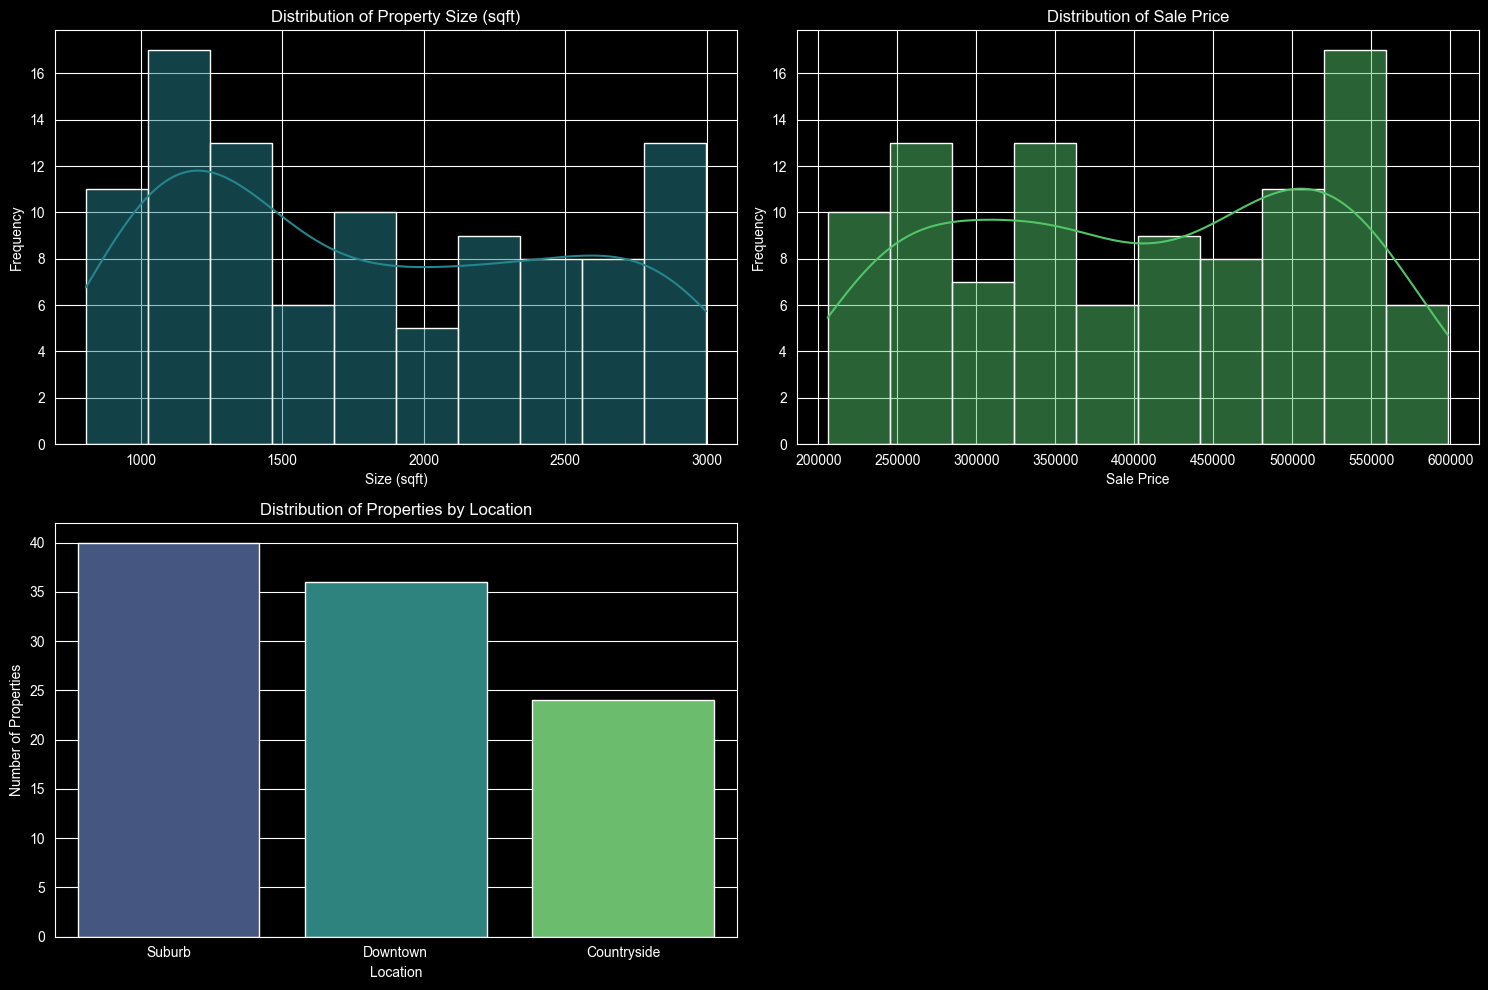

In [3]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(property_data["Size_sqft"], kde=True, color=colors[4], bins=10)
plt.title('Distribution of Property Size (sqft)')
plt.xlabel('Size (sqft)')
plt.ylabel('Frequency')


plt.subplot( 2, 2, 2)
sns.histplot(property_data["SalePrice"], kde=True, color=colors[7], bins=10)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.subplot( 2, 2, 3)
sns.countplot(data=property_data, x="Location", hue="Location", palette="viridis")
plt.title('Distribution of Properties by Location')
plt.xlabel('Location')
plt.ylabel('Number of Properties')

plt.tight_layout()
plt.show()


# Relationship analysis

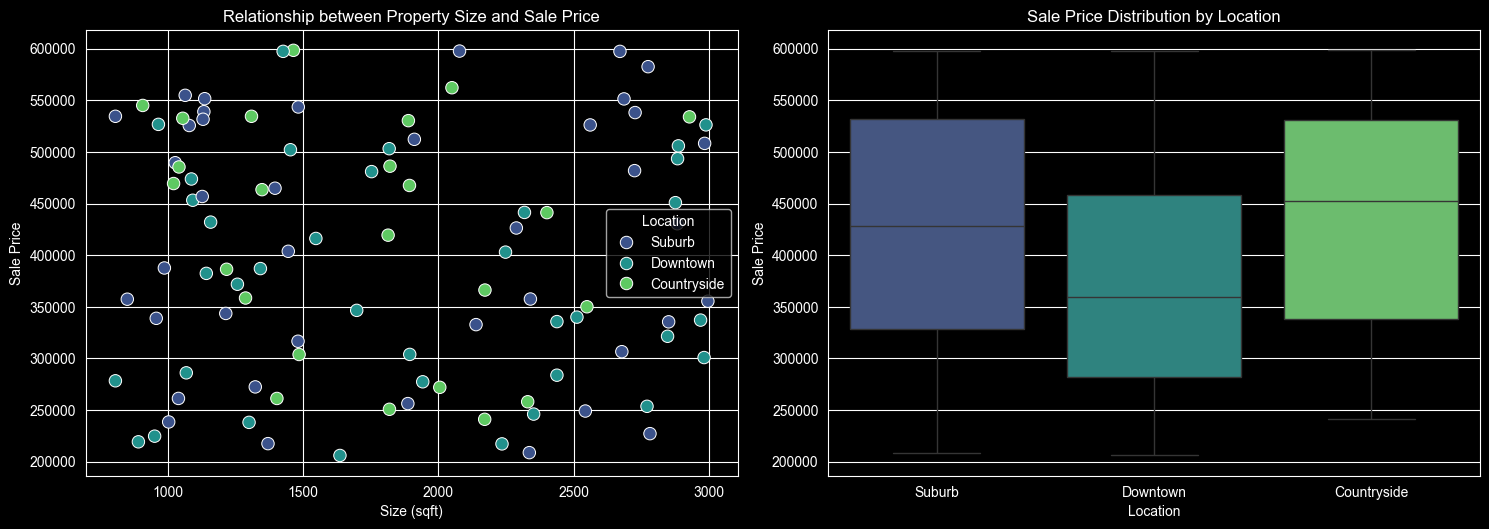

In [4]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(data =property_data, x="Size_sqft", y="SalePrice", hue="Location", palette="viridis", s= 80)
plt.title('Relationship between Property Size and Sale Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Sale Price')

plt.subplot(2, 2, 2)
sns.boxplot(data=property_data, x="Location", y="SalePrice", hue="Location", palette="viridis")
plt.title('Sale Price Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.show()

# Correlation analysis

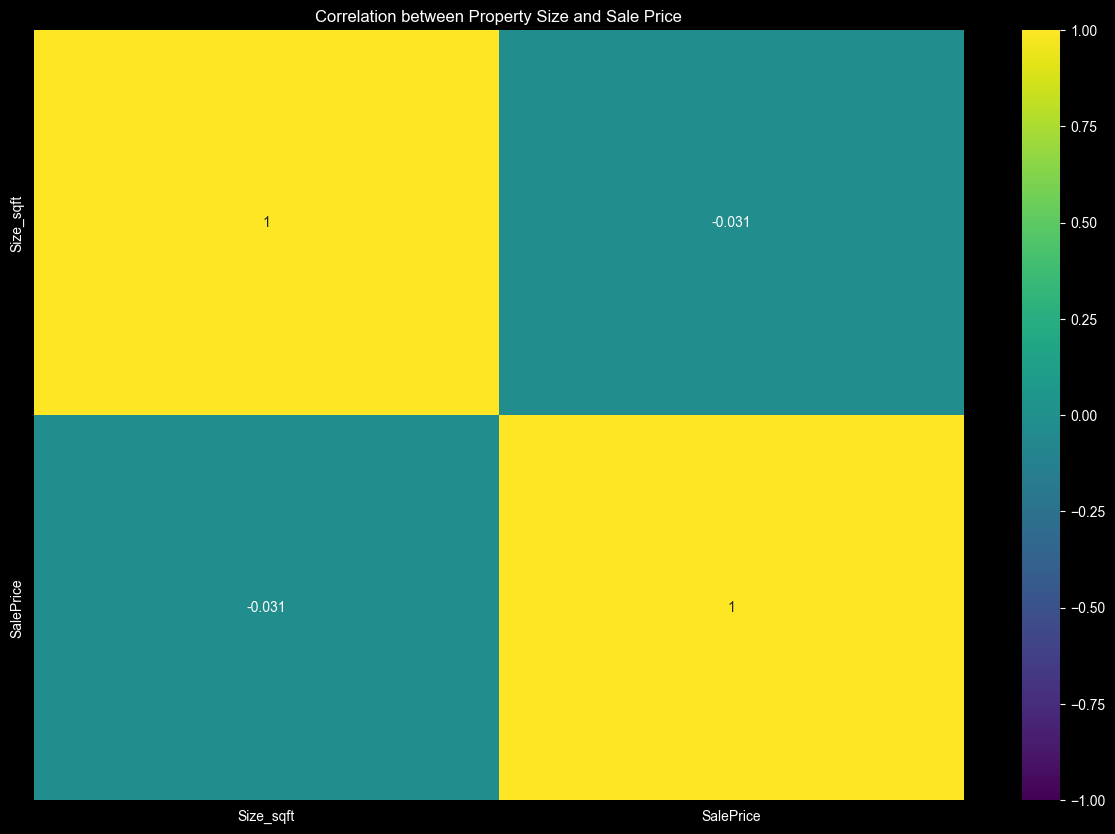

In [5]:
correlation_info = property_data[['Size_sqft', 'SalePrice']].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_info, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Correlation between Property Size and Sale Price')

plt.show()

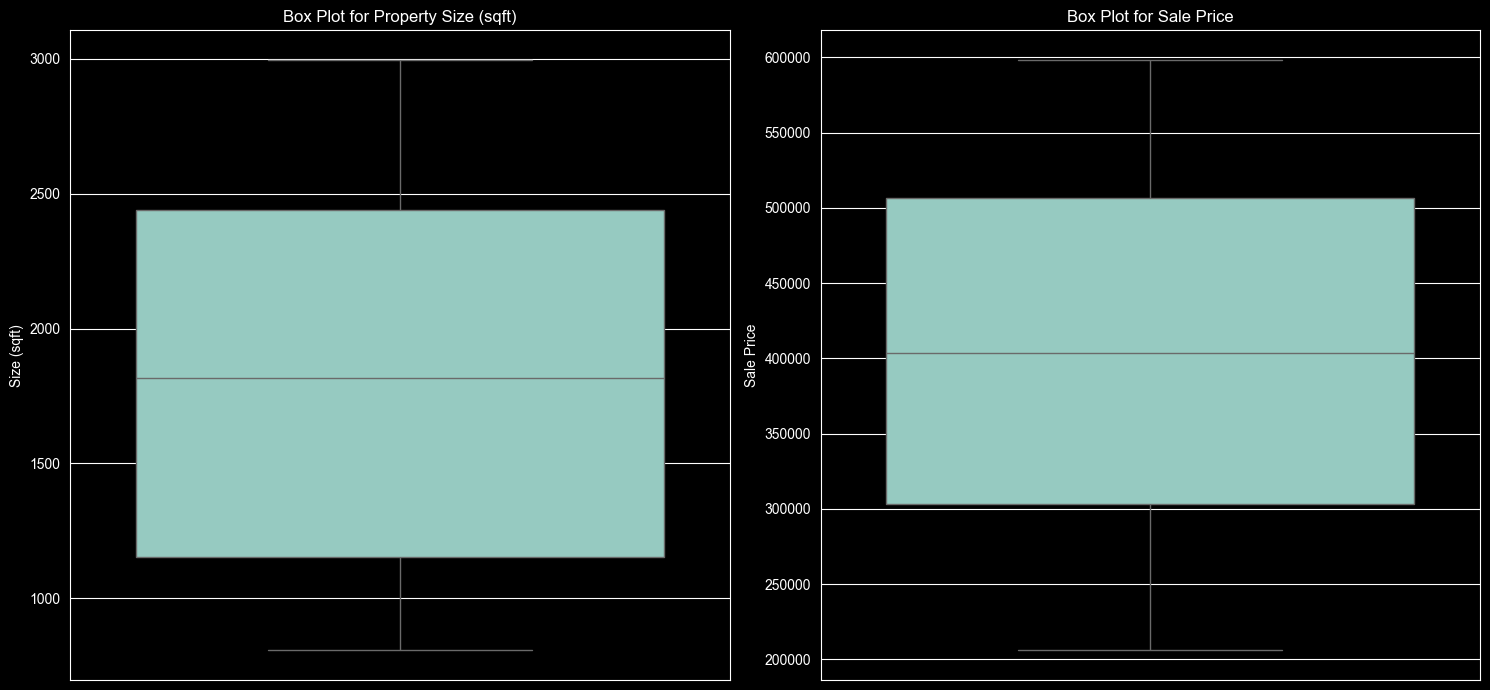

In [12]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.boxplot(data=property_data, y = "Size_sqft")
plt.title('Box Plot for Property Size (sqft)')
plt.ylabel('Size (sqft)')

plt.subplot(1, 2, 2)
sns.boxplot(data=property_data, y='SalePrice')
plt.title('Box Plot for Sale Price')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.show()

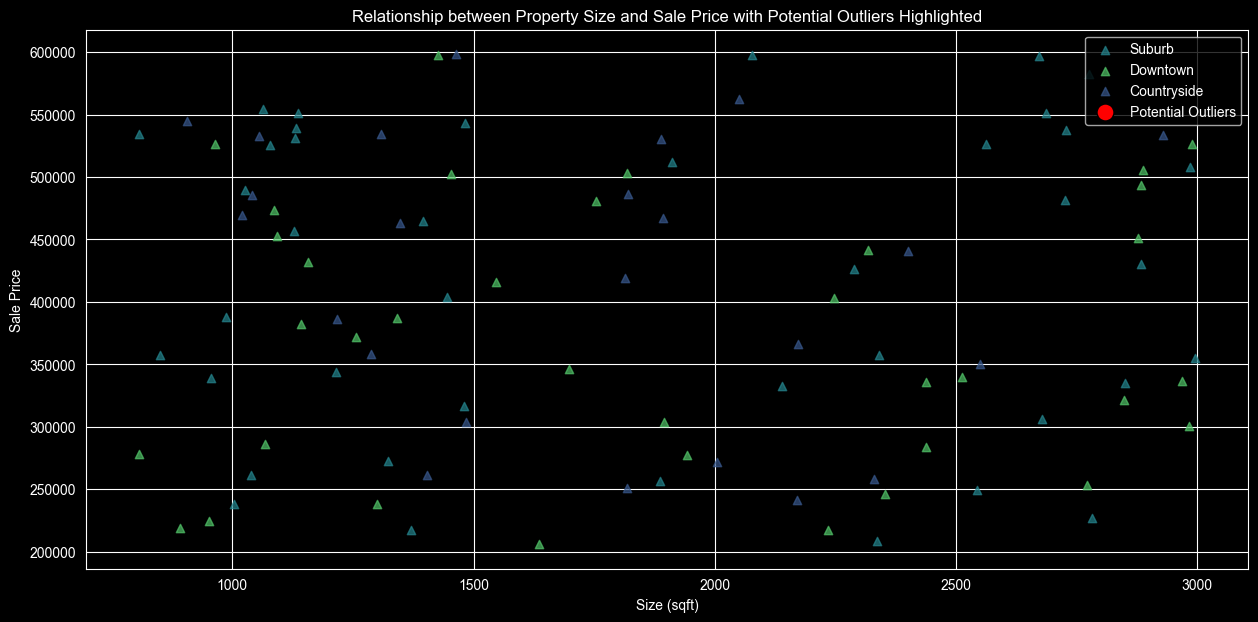

In [18]:
Q1 = property_data["SalePrice"].quantile(0.25)
Q3 = property_data["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = property_data[(property_data["SalePrice"] < lower_bound) |  (property_data['SalePrice'] > upper_bound)]
plt.figure(figsize=(15, 7))

# Scatter plot for regular data points
for location, color in zip(['Suburb', 'Downtown', 'Countryside'], [colors[4], colors[7], colors[2]]):
    subset = property_data[property_data['Location'] == location]
    plt.scatter(subset['Size_sqft'], subset['SalePrice'], color=color, label=location, marker='^', alpha=0.7)

# Highlighting the outliers
plt.scatter(outliers['Size_sqft'], outliers['SalePrice'], color='red', label='Potential Outliers', s=150, edgecolors='black')

plt.title('Relationship between Property Size and Sale Price with Potential Outliers Highlighted')
plt.xlabel('Size (sqft)')
plt.ylabel('Sale Price')
plt.legend()

plt.show()

C:\Users\dasar\AppData\Local\Temp\ipykernel_10256\1276356275.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=property_data, x='Location', palette='viridis')


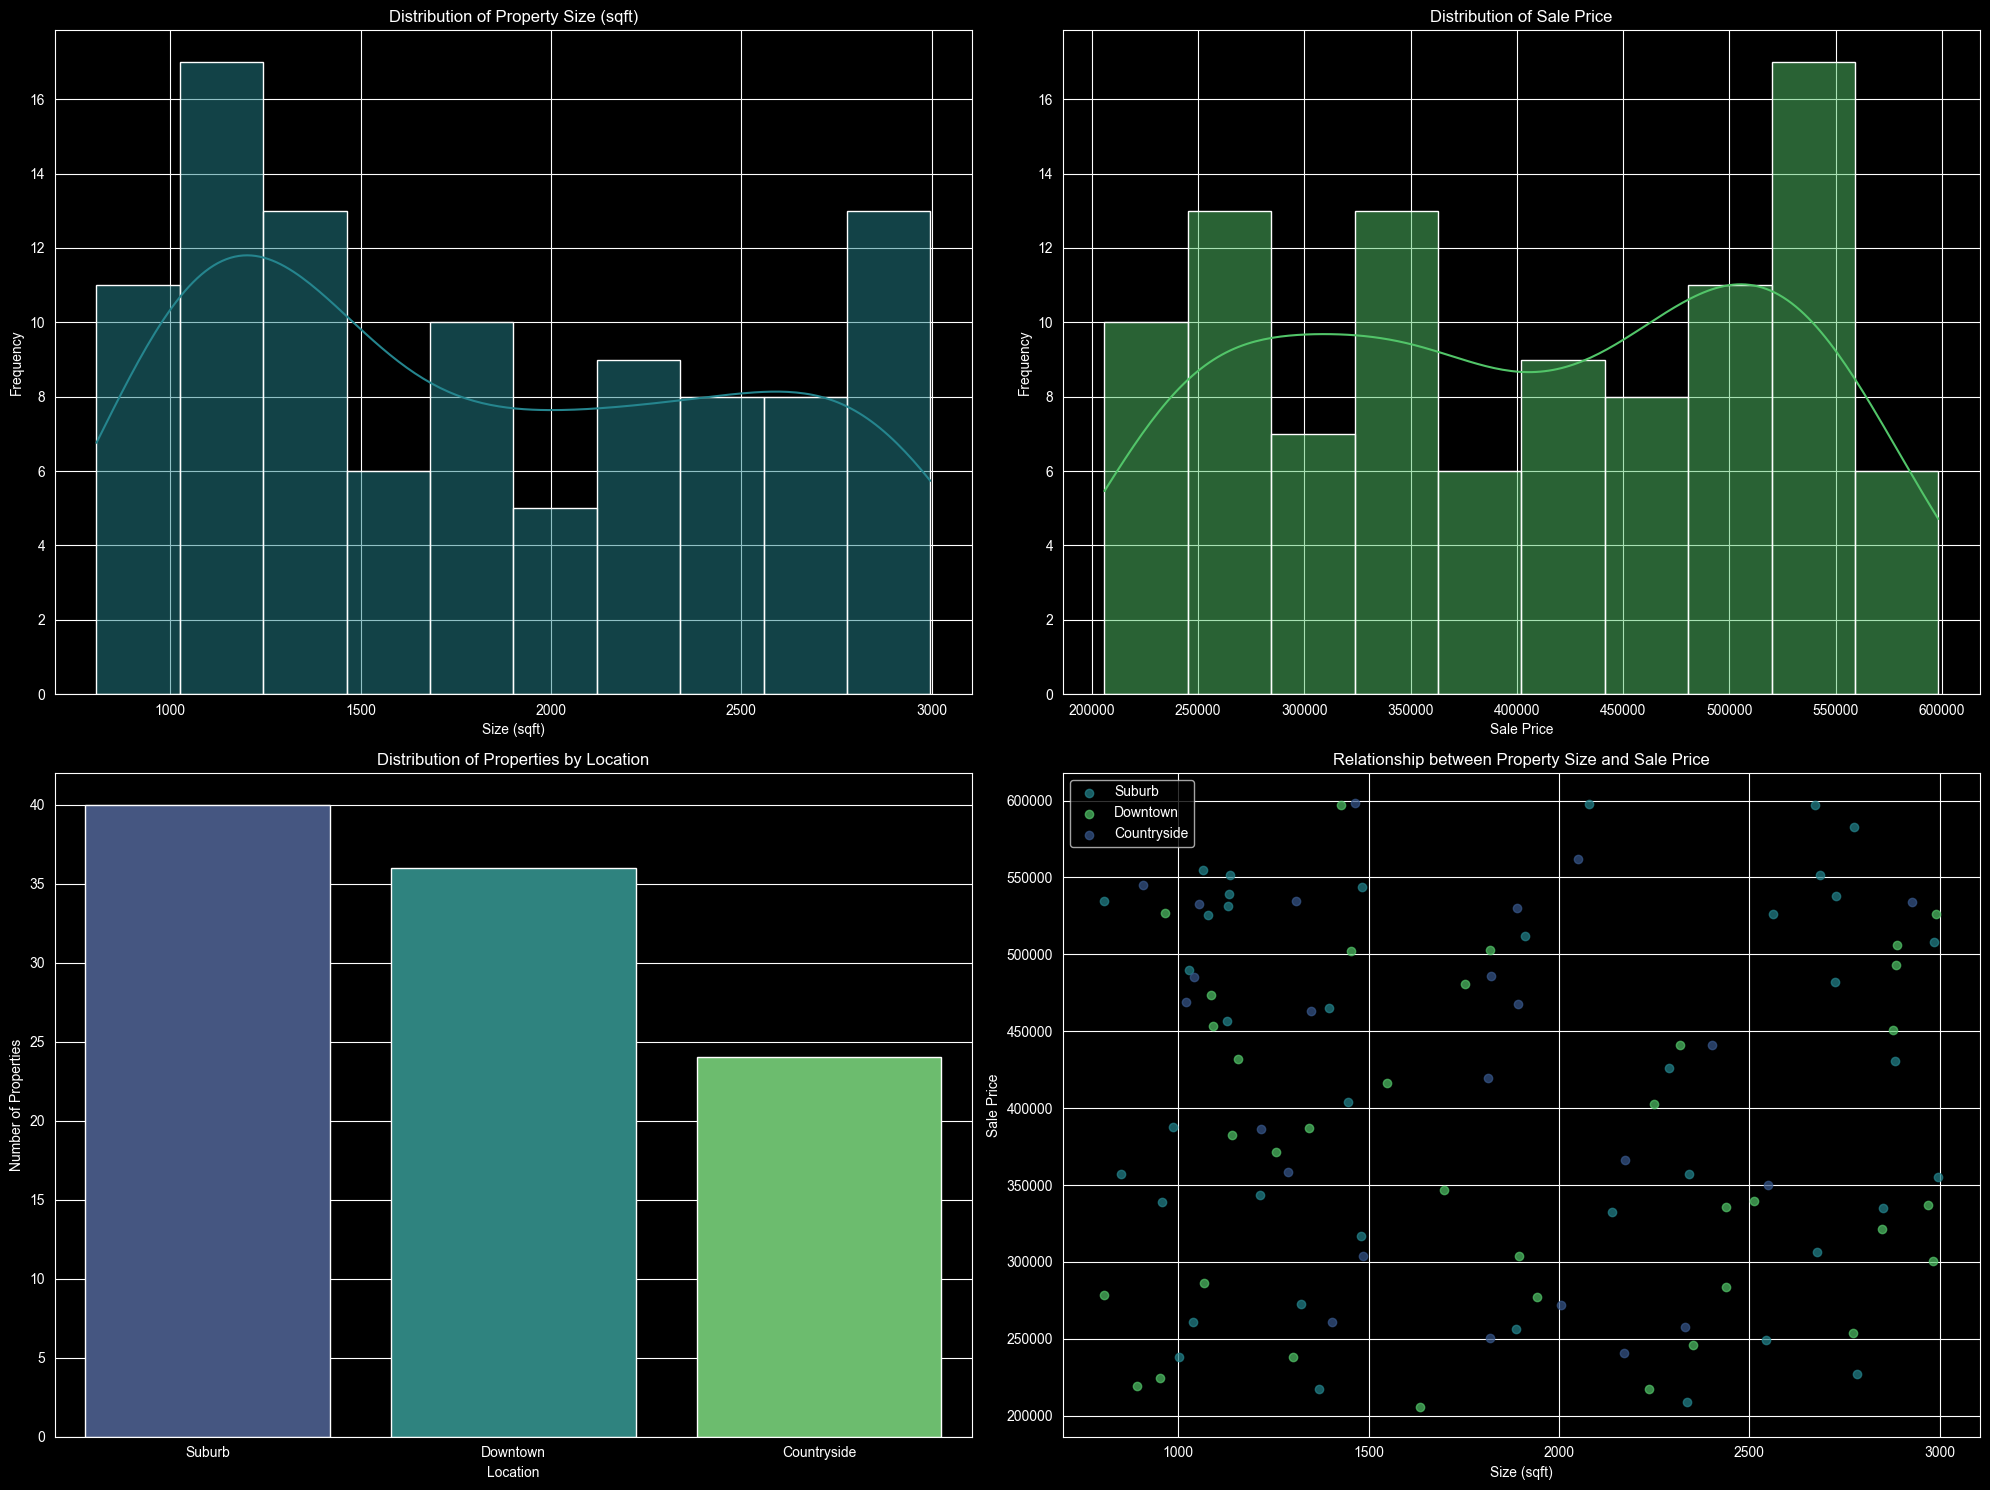

In [19]:
plt.figure(figsize=(20, 15))

# 1. Distribution of Property Size (sqft)
plt.subplot(2, 2, 1)
sns.histplot(property_data['Size_sqft'], kde=True, color=colors[4], bins=10)
plt.title('Distribution of Property Size (sqft)')
plt.xlabel('Size (sqft)')
plt.ylabel('Frequency')

# 2. Distribution of Sale Price
plt.subplot(2, 2, 2)
sns.histplot(property_data['SalePrice'], kde=True, color=colors[7], bins=10)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

# 3. Distribution of Properties by Location
plt.subplot(2, 2, 3)
sns.countplot(data=property_data, x='Location', palette='viridis')
plt.title('Distribution of Properties by Location')
plt.xlabel('Location')
plt.ylabel('Number of Properties')

# 4. Relationship between Property Size and Sale Price with location as hue (circle markers)
plt.subplot(2, 2, 4)
for location, color in zip(['Suburb', 'Downtown', 'Countryside'], [colors[4], colors[7], colors[2]]):
    subset = property_data[property_data['Location'] == location]
    plt.scatter(subset['Size_sqft'], subset['SalePrice'], color=color, label=location, alpha=0.7)

plt.title('Relationship between Property Size and Sale Price')
plt.xlabel('Size (sqft)')
plt.ylabel('Sale Price')
plt.legend()

plt.tight_layout()
plt.show()